#  Zomato Restaurant Data Analysis

This project analyzes restaurant data to identify factors affecting ratings.
The goal is to explore how cost, location, and customer engagement (votes) influence restaurant performance.

We perform data cleaning, visualization, and extract meaningful insights.


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df=pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


Data Understanding

In [4]:
df.shape

(51717, 17)

In [5]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


**Observation:**
The dataset contains information about restaurants including ratings, cost, location, and votes.


Data Cleaning

Clean Rating Column

In [9]:
df['rate']=df['rate'].replace(['NEW','-'],np.nan)
df['rate']=df['rate'].apply(lambda x:str(x).split('/')[0])
df['rate']=pd.to_numeric(df['rate'],errors='coerce')

In [10]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

Clean Cost Column

In [11]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

Clean Votes

In [12]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

Drop Unnecessary Columns

In [13]:
df.drop(['url','phone','dish_liked','reviews_list','menu_item'],axis=1,inplace=True)

Handle Missing Values

In [15]:
df.dropna(subset=['rate','votes','approx_cost(for two people)','location'],inplace=True)

**Observation:**
Data cleaning was performed to handle missing values and convert columns into appropriate formats for analysis.


EXPLORATORY DATA ANALYSIS

 Cost vs Rating

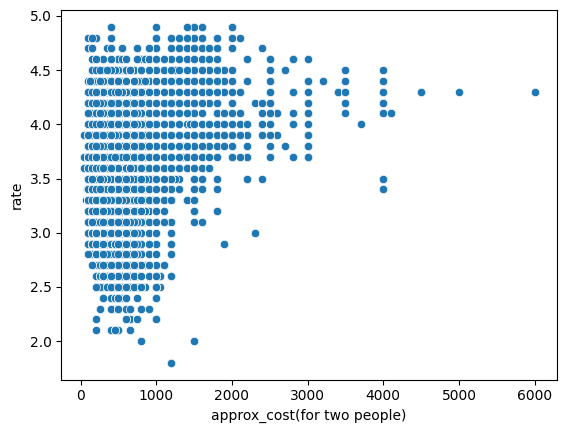

In [16]:
sns.scatterplot(x='approx_cost(for two people)',y='rate',data=df)
plt.show()

**Insight:**
There is no strong relationship between cost and rating. Higher-priced restaurants do not necessarily have better ratings.


Votes vs Rating

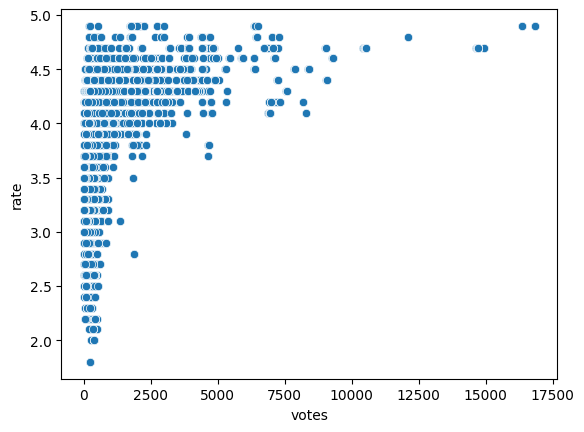

In [18]:
sns.scatterplot(x='votes',y='rate',data=df)
plt.show()

**Insight:**
There is no strict linear relationship between votes and ratings. However, restaurants with very high ratings tend to receive more votes, indicating that popular restaurants are often well-rated.


Top Locations

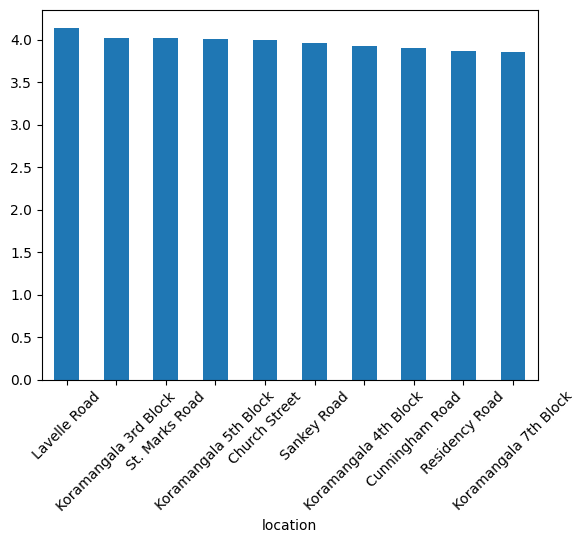

In [19]:
top_loc=df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)
top_loc.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

**Insight:**
Certain locations consistently show higher average ratings, suggesting that location plays a significant role in restaurant performance.


Online Order Impact

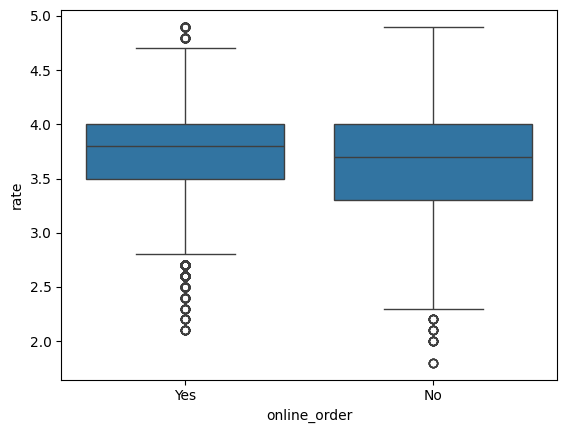

In [20]:
sns.boxplot(x='online_order',y='rate',data=df)
plt.show()

**Insight:**
Online ordering does not significantly impact restaurant ratings, as the distributions are similar.


Correlation Analysis

In [22]:
corr=df[['votes','rate','approx_cost(for two people)']].corr()
corr

,votes,rate,approx_cost(for two people)
votes,1.000000,0.434764,0.366700
rate,0.434764,1.000000,0.385183
approx_cost(for two people),0.366700,0.385183,1.000000


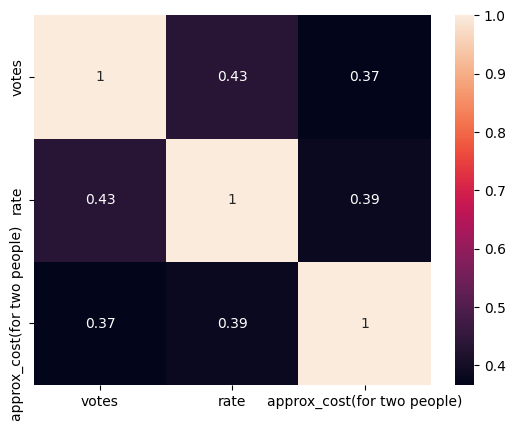

In [24]:
sns.heatmap(corr,annot=True)
plt.show()


**Insight:**

* The correlation between votes and rating is low to moderate, indicating that higher popularity does not always guarantee higher ratings.
* The relationship between cost and rating is weak, suggesting that expensive restaurants do not necessarily provide better customer satisfaction.
* Overall, ratings are influenced by multiple factors and cannot be explained by a single variable.


CONCLUSION

## Conclusion

* Ratings are more influenced by votes than cost
* Cost has a weak relationship with ratings
* Location plays a major role in restaurant success
* Online ordering has minimal impact on ratings

This analysis helps understand key factors that influence restaurant performance.
